# Загрузка библиотек

In [1]:
!pip install pandas
!pip install seaborn
!pip install matplotlib
!pip install phik
!pip install scikit-learn
!pip install lightgbm


[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: C:\test_sibintec\myvenv\Scripts\python.exe -m pip install --upgrade pip



[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: C:\test_sibintec\myvenv\Scripts\python.exe -m pip install --upgrade pip



[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: C:\test_sibintec\myvenv\Scripts\python.exe -m pip install --upgrade pip



[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: C:\test_sibintec\myvenv\Scripts\python.exe -m pip install --upgrade pip



[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: C:\test_sibintec\myvenv\Scripts\python.exe -m pip install --upgrade pip



[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: C:\test_sibintec\myvenv\Scripts\python.exe -m pip install --upgrade pip


In [2]:
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import phik
from phik import resources

from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, RobustScaler

import lightgbm as lgb

warnings.filterwarnings('ignore')

In [3]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# EDA

In [4]:
df = pd.read_csv('data/SWaT_Dataset_Attack_v0.csv', sep=';')

In [5]:
df.head()

,Timestamp,FIT101,LIT101,MV101,P101,P102,AIT201,AIT202,AIT203,FIT201,MV201,P201,P202,P203,P204,P205,P206,DPIT301,FIT301,LIT301,MV301,MV302,MV303,MV304,P301,P302,AIT401,AIT402,FIT401,LIT401,P401,P402,P403,P404,UV401,AIT501,AIT502,AIT503,AIT504,FIT501,FIT502,FIT503,FIT504,P501,P502,PIT501,PIT502,PIT503,FIT601,P601,P602,P603,Normal/Attack
0,28/12/2015 10:00:00 AM,"2,427057","522,8467",2,2,1,"262,0161","8,396437","328,6337","2,445391",2,1,1,2,1,2,1,"19,74838","2,206835","956,1651",1,2,1,1,1,2,"148,808","156,0882","1,713517","942,0662",1,2,1,1,2,"7,878621","145,1166","264,5475","12,03538","1,723789","1,279621","0,7352687","0,3077859",2,1,"250,8652","1,649953","189,5988","0,000128152",1,1,1,Normal
1,28/12/2015 10:00:01 AM,"2,446274","522,886",2,2,1,"262,0161","8,396437","328,6337","2,445391",2,1,1,2,1,2,1,"19,74838","2,208244","956,1651",1,2,1,1,1,2,"148,808","156,0882","1,715952","942,0277",1,2,1,1,2,"7,878621","145,1166","264,5475","12,03538","1,723789","1,297554","0,7352687","0,3077859",2,1,"250,8652","1,649953","189,6789","0,000128152",1,1,1,Normal
2,28/12/2015 10:00:02 AM,"2,489191","522,8467",2,2,1,"262,0161","8,394514","328,6337","2,442316",2,1,1,2,1,2,1,"19,69076","2,208628","956,4855",1,2,1,1,1,2,"148,808","156,0882","1,715952","941,8739",1,2,1,1,2,"7,878621","145,1166","264,5475","12,03538","1,723404","1,293967","0,7352687","0,3086186",2,1,"250,8812","1,649953","189,6789","0,000128152",1,1,1,Normal
3,28/12/2015 10:00:03 AM,"2,53435","522,9645",2,2,1,"262,0161","8,394514","328,6337","2,442316",2,1,1,2,1,2,1,"19,69076","2,208628","956,806",1,2,1,1,1,2,"148,808","156,0882","1,71467","941,797",1,2,1,1,2,"7,878621","145,0141","264,5475","12,03538","1,723404","1,281158","0,7352687","0,3086186",2,1,"250,8812","1,649953","189,6148","0,000128152",1,1,1,Normal
4,28/12/2015 10:00:04 AM,"2,56926","523,4748",2,2,1,"262,0161","8,394514","328,6337","2,443085",2,1,1,2,1,2,1,"19,69076","2,208628","957,0864",1,2,1,1,1,2,"148,808","156,0882","1,71467","942,22",1,2,1,1,2,"7,878621","144,8859","264,5475","12,03538","1,723404","1,281158","0,7352687","0,3086186",2,1,"250,8812","1,649953","189,5027","0,000128152",1,1,1,Normal


In [6]:
df.value_counts().sum()

np.int64(449919)

In [7]:
df["Normal/Attack"].value_counts()

Normal/Attack
Normal     395298
Attack      54584
A ttack        37
Name: count, dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

## Преобразование данных

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 449919 entries, 0 to 449918
Data columns (total 53 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Timestamp      449919 non-null  str   
 1   FIT101         449919 non-null  object
 2   LIT101         449919 non-null  str   
 3   MV101          449919 non-null  int64 
 4   P101           449919 non-null  int64 
 5   P102           449919 non-null  int64 
 6   AIT201         449919 non-null  str   
 7   AIT202         449919 non-null  str   
 8   AIT203         449919 non-null  str   
 9   FIT201         449919 non-null  object
 10  MV201          449919 non-null  int64 
 11  P201           449919 non-null  int64 
 12  P202           449919 non-null  int64 
 13  P203           449919 non-null  int64 
 14  P204           449919 non-null  int64 
 15  P205           449919 non-null  int64 
 16  P206           449919 non-null  int64 
 17  DPIT301        449919 non-null  str   
 18  FIT301         

In [10]:
cols_to_convert = [col for col in df.columns 
                   if df[col].dtype == 'object' or df[col].dtype == 'str'
                   and col not in ['Timestamp', 'Normal/Attack']]

for col in cols_to_convert:
    df[col] = df[col].str.replace(',', '.').astype(float)

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 449919 entries, 0 to 449918
Data columns (total 53 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Timestamp      449919 non-null  str    
 1   FIT101         433535 non-null  float64
 2   LIT101         449919 non-null  float64
 3   MV101          449919 non-null  int64  
 4   P101           449919 non-null  int64  
 5   P102           449919 non-null  int64  
 6   AIT201         449919 non-null  float64
 7   AIT202         449919 non-null  float64
 8   AIT203         449919 non-null  float64
 9   FIT201         433535 non-null  float64
 10  MV201          449919 non-null  int64  
 11  P201           449919 non-null  int64  
 12  P202           449919 non-null  int64  
 13  P203           449919 non-null  int64  
 14  P204           449919 non-null  int64  
 15  P205           449919 non-null  int64  
 16  P206           449919 non-null  int64  
 17  DPIT301        449919 non-null  float64


In [12]:
df['Normal/Attack'].value_counts()

Normal/Attack
Normal     395298
Attack      54584
A ttack        37
Name: count, dtype: int64

1 - 'Attack' <br>
0 - 'Normal'

In [13]:
df['Normal/Attack'] = df['Normal/Attack'].replace('A ttack', 'Attack')
df['target'] = (df['Normal/Attack'] == 'Attack').astype(int)
df.drop('Normal/Attack', axis=1, inplace=True)

In [14]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'].str.strip(), format='%d/%m/%Y %I:%M:%S %p')

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.isna().sum()

Timestamp        0
FIT101       16384
LIT101           0
MV101            0
P101             0
P102             0
AIT201           0
AIT202           0
AIT203           0
FIT201       16384
MV201            0
P201             0
P202             0
P203             0
P204             0
P205             0
P206             0
DPIT301          0
FIT301           0
LIT301           0
MV301            0
MV302            0
MV303            0
MV304            0
P301             0
P302             0
AIT401           0
AIT402           0
FIT401       16384
LIT401           0
P401             0
P402             0
P403             0
P404             0
UV401            0
AIT501           0
AIT502           0
AIT503           0
AIT504           0
FIT501           0
FIT502           0
FIT503           0
FIT504           0
P501             0
P502             0
PIT501           0
PIT502       16384
PIT503           0
FIT601           0
P601             0
P602             0
P603             0
target      

**Гипотезы по пропускам:**

- Возможно пропуски и связаны с атаками и являются важным признаком
- Возможно пропуски связаны с отказом оборудования (FIT - показывает расход воды, PIT - давление в трубопроводах). Почему именно в этих..?
- Возможно из стоит заплонить ближайшеми значениями, так как измерения производятся каждую секунду

In [17]:
print('FIT101 NaN & target=0:', df[(df['FIT101'].isna()) & (df['target'] == 0)].shape[0])
print('FIT201 NaN & target=0:', df[(df['FIT201'].isna()) & (df['target'] == 0)].shape[0])
print('FIT401 NaN & target=0:', df[(df['FIT401'].isna()) & (df['target'] == 0)].shape[0])
print('PIT502 NaN & target=0:', df[(df['PIT502'].isna()) & (df['target'] == 0)].shape[0])
print('Совпадение пропусков:',  df[(df['FIT101'].isna()) & (df['FIT201'].isna()) & (df['FIT401'].isna()) & (df['PIT502'].isna())].shape[0])

FIT101 NaN & target=0: 0
FIT201 NaN & target=0: 0
FIT401 NaN & target=0: 0
PIT502 NaN & target=0: 0
Совпадение пропусков: 16384


In [18]:
df[df['FIT101'].isna()].head()

,Timestamp,FIT101,LIT101,MV101,P101,P102,AIT201,AIT202,AIT203,FIT201,MV201,P201,P202,P203,P204,P205,P206,DPIT301,FIT301,LIT301,MV301,MV302,MV303,MV304,P301,P302,AIT401,AIT402,FIT401,LIT401,P401,P402,P403,P404,UV401,AIT501,AIT502,AIT503,AIT504,FIT501,FIT502,FIT503,FIT504,P501,P502,PIT501,PIT502,PIT503,FIT601,P601,P602,P603,target
245760,2015-12-31 06:16:00,NaN,814.3770,1,1,1,192.8672,8.589977,350.2179,NaN,1,1,1,1,1,1,1,2.003969,0.0,1015.685,1,1,1,2,1,1,148.808,330.8126,NaN,248.1671,1,1,1,1,1,7.535440,234.2733,267.7839,15.53448,0.000897,0.001153,0.000896,0.0,1,1,10.06152,NaN,3.733017,0.0,1,1,1,1
245761,2015-12-31 06:16:01,NaN,814.2985,1,1,1,192.8672,8.589977,350.2179,NaN,1,1,1,1,1,1,1,2.003969,0.0,1015.485,1,1,1,2,1,1,148.808,330.8126,NaN,248.2440,1,1,1,1,1,7.535440,234.2733,267.7839,15.53448,0.000897,0.001153,0.000896,0.0,1,1,10.06152,NaN,3.733017,0.0,1,1,1,1
245762,2015-12-31 06:16:02,NaN,813.8275,1,1,1,192.8672,8.589977,350.2179,NaN,1,1,1,1,1,1,1,2.003969,0.0,1015.685,1,1,1,2,1,1,148.808,330.8126,NaN,248.3209,1,1,1,1,1,7.535440,234.2733,267.7839,15.53448,0.000897,0.001153,0.000896,0.0,1,1,10.06152,NaN,3.733017,0.0,1,1,1,1
245763,2015-12-31 06:16:03,NaN,813.9059,1,1,1,192.8672,8.589977,350.2179,NaN,1,1,1,1,1,1,1,2.003969,0.0,1015.685,1,1,1,2,1,1,148.808,330.8126,NaN,248.3594,1,1,1,1,1,7.536401,234.2733,267.7839,15.53448,0.000897,0.001153,0.000896,0.0,1,1,10.06152,NaN,3.733017,0.0,1,1,1,1
245764,2015-12-31 06:16:04,NaN,814.0237,1,1,1,192.8672,8.589977,350.2179,NaN,1,1,1,1,1,1,1,2.003969,0.0,1015.445,1,1,1,2,1,1,148.808,330.8126,NaN,247.9749,1,1,1,1,1,7.537042,234.2733,267.7839,15.53448,0.000897,0.001153,0.000896,0.0,1,1,10.06152,NaN,3.733017,0.0,1,1,1,1


In [19]:
df[df['FIT101'].isna()].tail()

,Timestamp,FIT101,LIT101,MV101,P101,P102,AIT201,AIT202,AIT203,FIT201,MV201,P201,P202,P203,P204,P205,P206,DPIT301,FIT301,LIT301,MV301,MV302,MV303,MV304,P301,P302,AIT401,AIT402,FIT401,LIT401,P401,P402,P403,P404,UV401,AIT501,AIT502,AIT503,AIT504,FIT501,FIT502,FIT503,FIT504,P501,P502,PIT501,PIT502,PIT503,FIT601,P601,P602,P603,target
262139,2015-12-31 10:48:59,NaN,812.6498,1,1,1,197.4494,8.524609,369.4694,NaN,1,1,1,1,1,1,1,2.035982,0.0,1016.566,1,1,1,2,1,1,148.808,326.3778,NaN,247.4750,1,1,1,1,1,7.440592,187.4648,269.9308,15.61138,0.001025,0.001153,0.001152,0.0,1,1,9.628942,NaN,3.316457,0.0,1,1,1,1
262140,2015-12-31 10:49:00,NaN,813.0031,1,1,1,197.4494,8.524609,369.4694,NaN,1,1,1,1,1,1,1,2.035982,0.0,1016.727,1,1,1,2,1,1,148.808,326.3778,NaN,247.0905,1,1,1,1,1,7.440592,187.4648,269.9308,15.61138,0.001025,0.001153,0.001152,0.0,1,1,9.628942,NaN,3.316457,0.0,1,1,1,1
262141,2015-12-31 10:49:01,NaN,812.9639,1,1,1,197.4494,8.524609,369.4694,NaN,1,1,1,1,1,1,1,2.035982,0.0,1016.767,1,1,1,2,1,1,148.808,326.3778,NaN,246.9367,1,1,1,1,1,7.440592,187.4648,269.9308,15.61138,0.001025,0.001153,0.001152,0.0,1,1,9.628942,NaN,3.316457,0.0,1,1,1,1
262142,2015-12-31 10:49:02,NaN,812.9639,1,1,1,197.4494,8.524609,369.4694,NaN,1,1,1,1,1,1,1,2.035982,0.0,1016.486,1,1,1,2,1,1,148.808,326.3778,NaN,246.9367,1,1,1,1,1,7.440592,187.4648,269.9308,15.61138,0.001025,0.001153,0.001152,0.0,1,1,9.628942,NaN,3.316457,0.0,1,1,1,1
262143,2015-12-31 10:49:03,NaN,813.2386,1,1,1,197.4494,8.524609,369.4694,NaN,1,1,1,1,1,1,1,2.035982,0.0,1016.767,1,1,1,2,1,1,148.808,326.3778,NaN,246.8982,1,1,1,1,1,7.440592,187.4648,269.9308,15.61138,0.001025,0.001153,0.001152,0.0,1,1,9.628942,NaN,3.316457,0.0,1,1,1,1


Пока что для базового решения примим теорию о том, что пропуски являются признаком атаки и важной информацией для модели. В случае реальной работы врядли такое решение подойдет (там стоит поглубже разобраться откуда пропуски, поискать больше законмерностей, сходить к инженерам/механникам и т.д.), но для тестового задания это может сильно улучшить качество модели. Плюс в пользу версии отказа оборудования гововрит, что все пропуски были в 1 день.

Заменю пропуск -1, потому что такое значение никогда не встречается.

In [20]:
df.describe()

,Timestamp,FIT101,LIT101,MV101,P101,P102,AIT201,AIT202,AIT203,FIT201,MV201,P201,P202,P203,P204,P205,P206,DPIT301,FIT301,LIT301,MV301,MV302,MV303,MV304,P301,P302,AIT401,AIT402,FIT401,LIT401,P401,P402,P403,P404,UV401,AIT501,AIT502,AIT503,AIT504,FIT501,FIT502,FIT503,FIT504,P501,P502,PIT501,PIT502,PIT503,FIT601,P601,P602,P603,target
count,449919,433535.000000,449919.000000,449919.000000,449919.000000,449919.000000,449919.000000,449919.000000,449919.000000,433535.000000,449919.000000,449919.000000,449919.0,449919.000000,449919.000000,449919.000000,449919.000000,449919.000000,449919.000000,449919.000000,449919.000000,449919.000000,449919.000000,449919.000000,449919.0,449919.000000,449919.000000,449919.000000,433535.000000,449919.000000,449919.0,449919.000000,449919.000000,449919.0,449919.000000,449919.000000,449919.000000,449919.000000,449919.000000,449919.000000,449919.000000,449919.000000,449919.000000,449919.000000,449919.0,449919.000000,433535.000000,449919.000000,449919.000000,449919.0,449919.000000,449919.0,449919.000000
mean,2015-12-31 00:29:46.199656,1.779134,607.019967,1.665335,1.693251,1.006946,210.297302,8.528535,320.301478,1.767263,1.691584,1.121068,1.0,1.690689,1.000124,1.691131,1.000122,15.827634,1.713555,910.076801,1.007321,1.749655,1.023349,1.101163,1.0,1.772946,148.805855,161.990135,1.650311,833.542913,1.0,1.928792,1.000133,1.0,1.925849,7.787358,147.509939,264.789668,14.504030,1.603014,1.195462,0.679549,0.283806,1.925862,1.0,232.173817,1.051706,174.714484,0.016566,1.0,1.009099,1.0,0.121402
min,2015-12-28 10:00:00,0.000000,189.826300,0.000000,1.000000,1.000000,168.033800,6.000000,285.337100,0.000000,0.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,364.386300,0.000000,0.000000,0.000000,0.000000,1.0,1.000000,148.759900,140.835700,0.000000,243.014600,1.0,1.000000,1.000000,1.0,1.000000,7.432902,129.838500,244.873100,9.536016,0.000000,0.000000,0.000000,0.000000,1.000000,1.0,9.468726,0.000000,3.140220,0.000000,1.0,1.000000,1.0,0.000000
25%,2015-12-29 17:14:39.500000,0.000000,510.011100,1.000000,1.000000,1.000000,177.102000,8.441618,306.383000,0.000000,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,19.316220,2.194664,836.444200,1.000000,2.000000,1.000000,1.000000,1.0,2.000000,148.803200,146.116400,1.710826,819.097700,1.0,2.000000,1.000000,1.0,2.000000,7.772879,138.990000,259.965400,13.035120,1.719559,1.272576,0.730660,0.306249,2.000000,1.0,248.029400,0.816967,186.698900,0.000000,1.0,1.000000,1.0,0.000000
50%,2015-12-31 00:29:19,2.485667,530.422500,2.000000,2.000000,1.000000,193.508100,8.551525,321.661100,2.447570,2.000000,1.000000,1.0,2.000000,1.000000,2.000000,1.000000,19.898840,2.201582,924.682800,1.000000,2.000000,1.000000,1.000000,1.0,2.000000,148.808000,150.166600,1.717874,884.427100,1.0,2.000000,1.000000,1.0,2.000000,7.797873,142.912100,264.387300,14.611640,1.726993,1.286410,0.732708,0.306633,2.000000,1.0,249.295100,0.977157,187.724300,0.000000,1.0,1.000000,1.0,0.000000
75%,2016-01-01 07:45:19.500000,2.582711,727.432100,2.000000,2.000000,1.000000,253.845200,8.610806,331.684200,2.454875,2.000000,1.000000,1.0,2.000000,1.000000,2.000000,1.000000,20.116530,2.207091,977.794200,1.000000,2.000000,1.000000,1.000000,1.0,2.000000,148.808000,153.652900,1.724282,937.375100,1.0,2.000000,1.000000,1.0,2.000000,7.840810,144.706500,269.129700,15.419120,1.733145,1.300115,0.734885,0.308106,2.000000,1.0,250.881200,1.409669,189.118200,0.000128,1.0,1.000000,1.0,0.000000
max,2016-01-02 14:59:59,2.760145,925.032300,2.000000,2.000000,2.000000,267.719800,8.733210,384.465500,2.826899,2.000000,2.000000,1.0,2.000000,2.000000,2.000000,2.000000,45.000000,2.376197,1201.000000,2.000000,2.000000,2.000000,2.000000,1.0,2.000000,148.856100,333.811800,1.744914,1002.781000,1.0,2.000000,2.000000,1.0,2.000000,8.307037,272.853100,297.263500,442.463500,1.753653,1.360318,0.741542,0.311693,2.000000,1.0,254.341800,1.970333,191.986000,1.802710,1.0,2.000000,1.0,1.000000
std,NaN,1.165586,125.303003,0.482323,0.461145,0.083051,35.

In [21]:
cols_with_nan = ['FIT101', 'FIT201', 'FIT401', 'PIT502']
df[cols_with_nan] = df[cols_with_nan].fillna(-1)

In [22]:
df.isna().sum().sum()

np.int64(0)

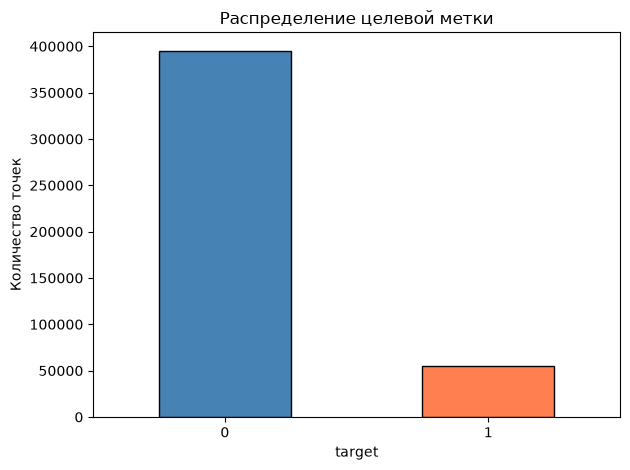

In [23]:
df['target'].value_counts().plot(kind='bar', color=['steelblue', 'coral'], edgecolor='black')
plt.title('Распределение целевой метки')
plt.ylabel('Количество точек')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [24]:
df['target'].value_counts(normalize=True) 

target
0    0.878598
1    0.121402
Name: proportion, dtype: float64

Присутствует дисбаланс, но не большой

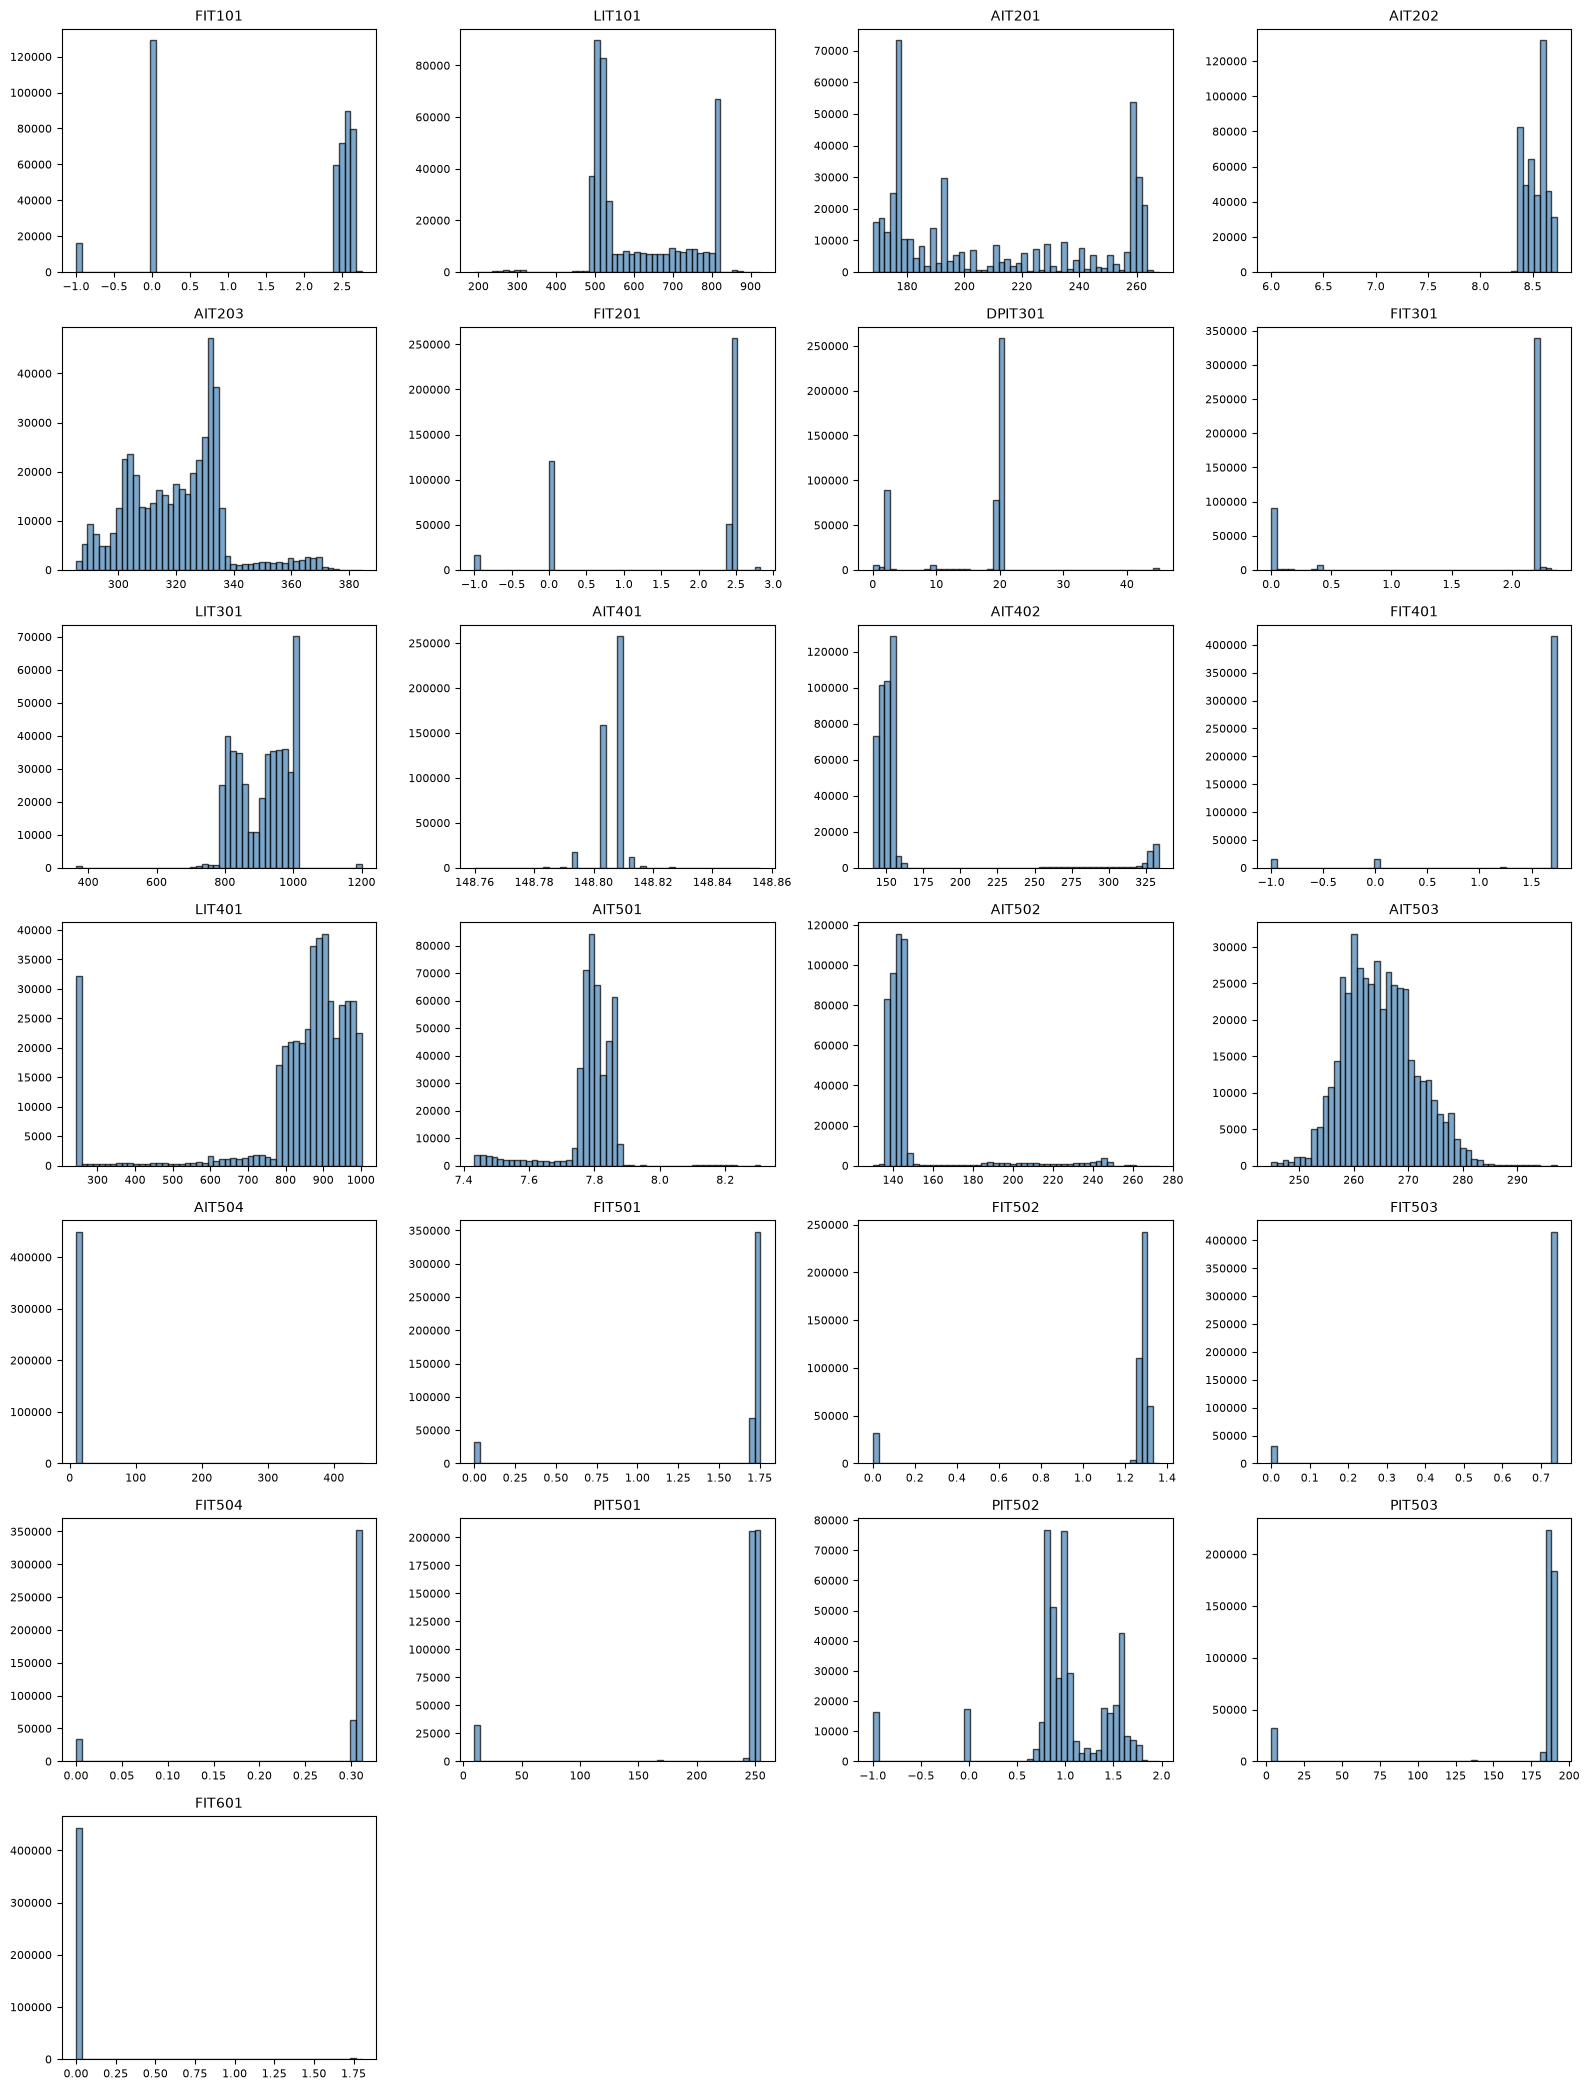

In [25]:
float_cols = df.select_dtypes(include='float64').columns.tolist()

for col in ['Timestamp', 'target']:
    if col in float_cols:
        float_cols.remove(col)

n_cols = 4
n_rows = math.ceil(len(float_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3 * n_rows))
axes = axes.flatten()

for i, col in enumerate(float_cols):
    ax = axes[i]
    ax.hist(df[col], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_title(col, fontsize=10)
    ax.tick_params(labelsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

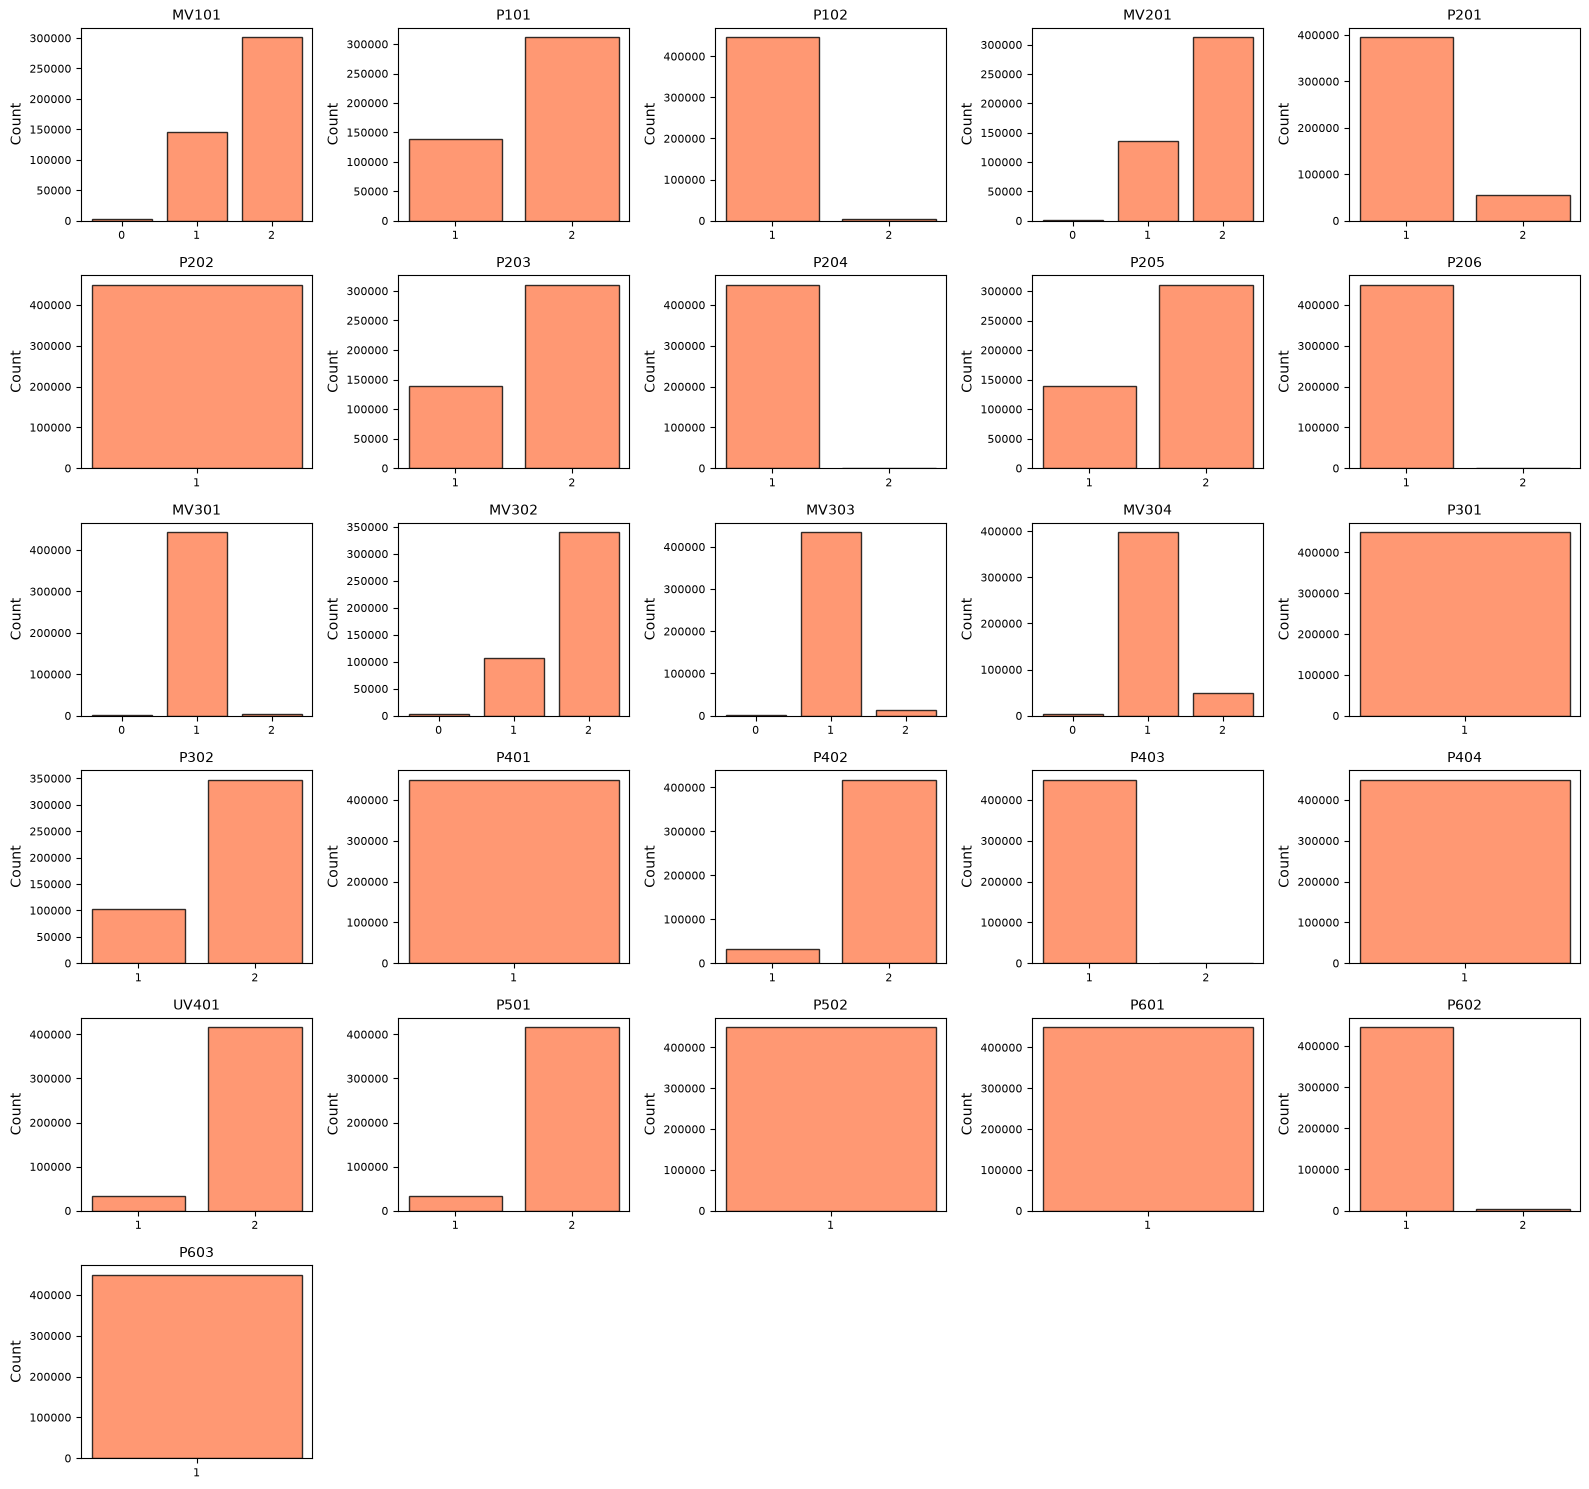

In [26]:
int_cols = df.select_dtypes(include='int64').columns.tolist()
for col in ['target', '']:        
    if col in int_cols:
        int_cols.remove(col)

n_cols = 5
n_rows = math.ceil(len(int_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 2.5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(int_cols):
    ax = axes[i]
    vc = df[col].value_counts().sort_index()
    ax.bar(vc.index.astype(str), vc.values, color='coral', edgecolor='black', alpha=0.8)
    ax.set_title(col, fontsize=10)
    ax.set_ylabel('Count')
    ax.tick_params(labelsize=8)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Можно дропнуть стролбцы P202, P301, P401, P404, P502, P601 и P603 - Потому что для решения данной задачи эти столбцы не несут информации (опять же врядли в реальной работе можно было бы поступить тк же).

In [27]:
df.drop(['P202', 'P301', 'P401', 'P404', 'P502', 'P601', 'P603'], axis=1, inplace=True) 

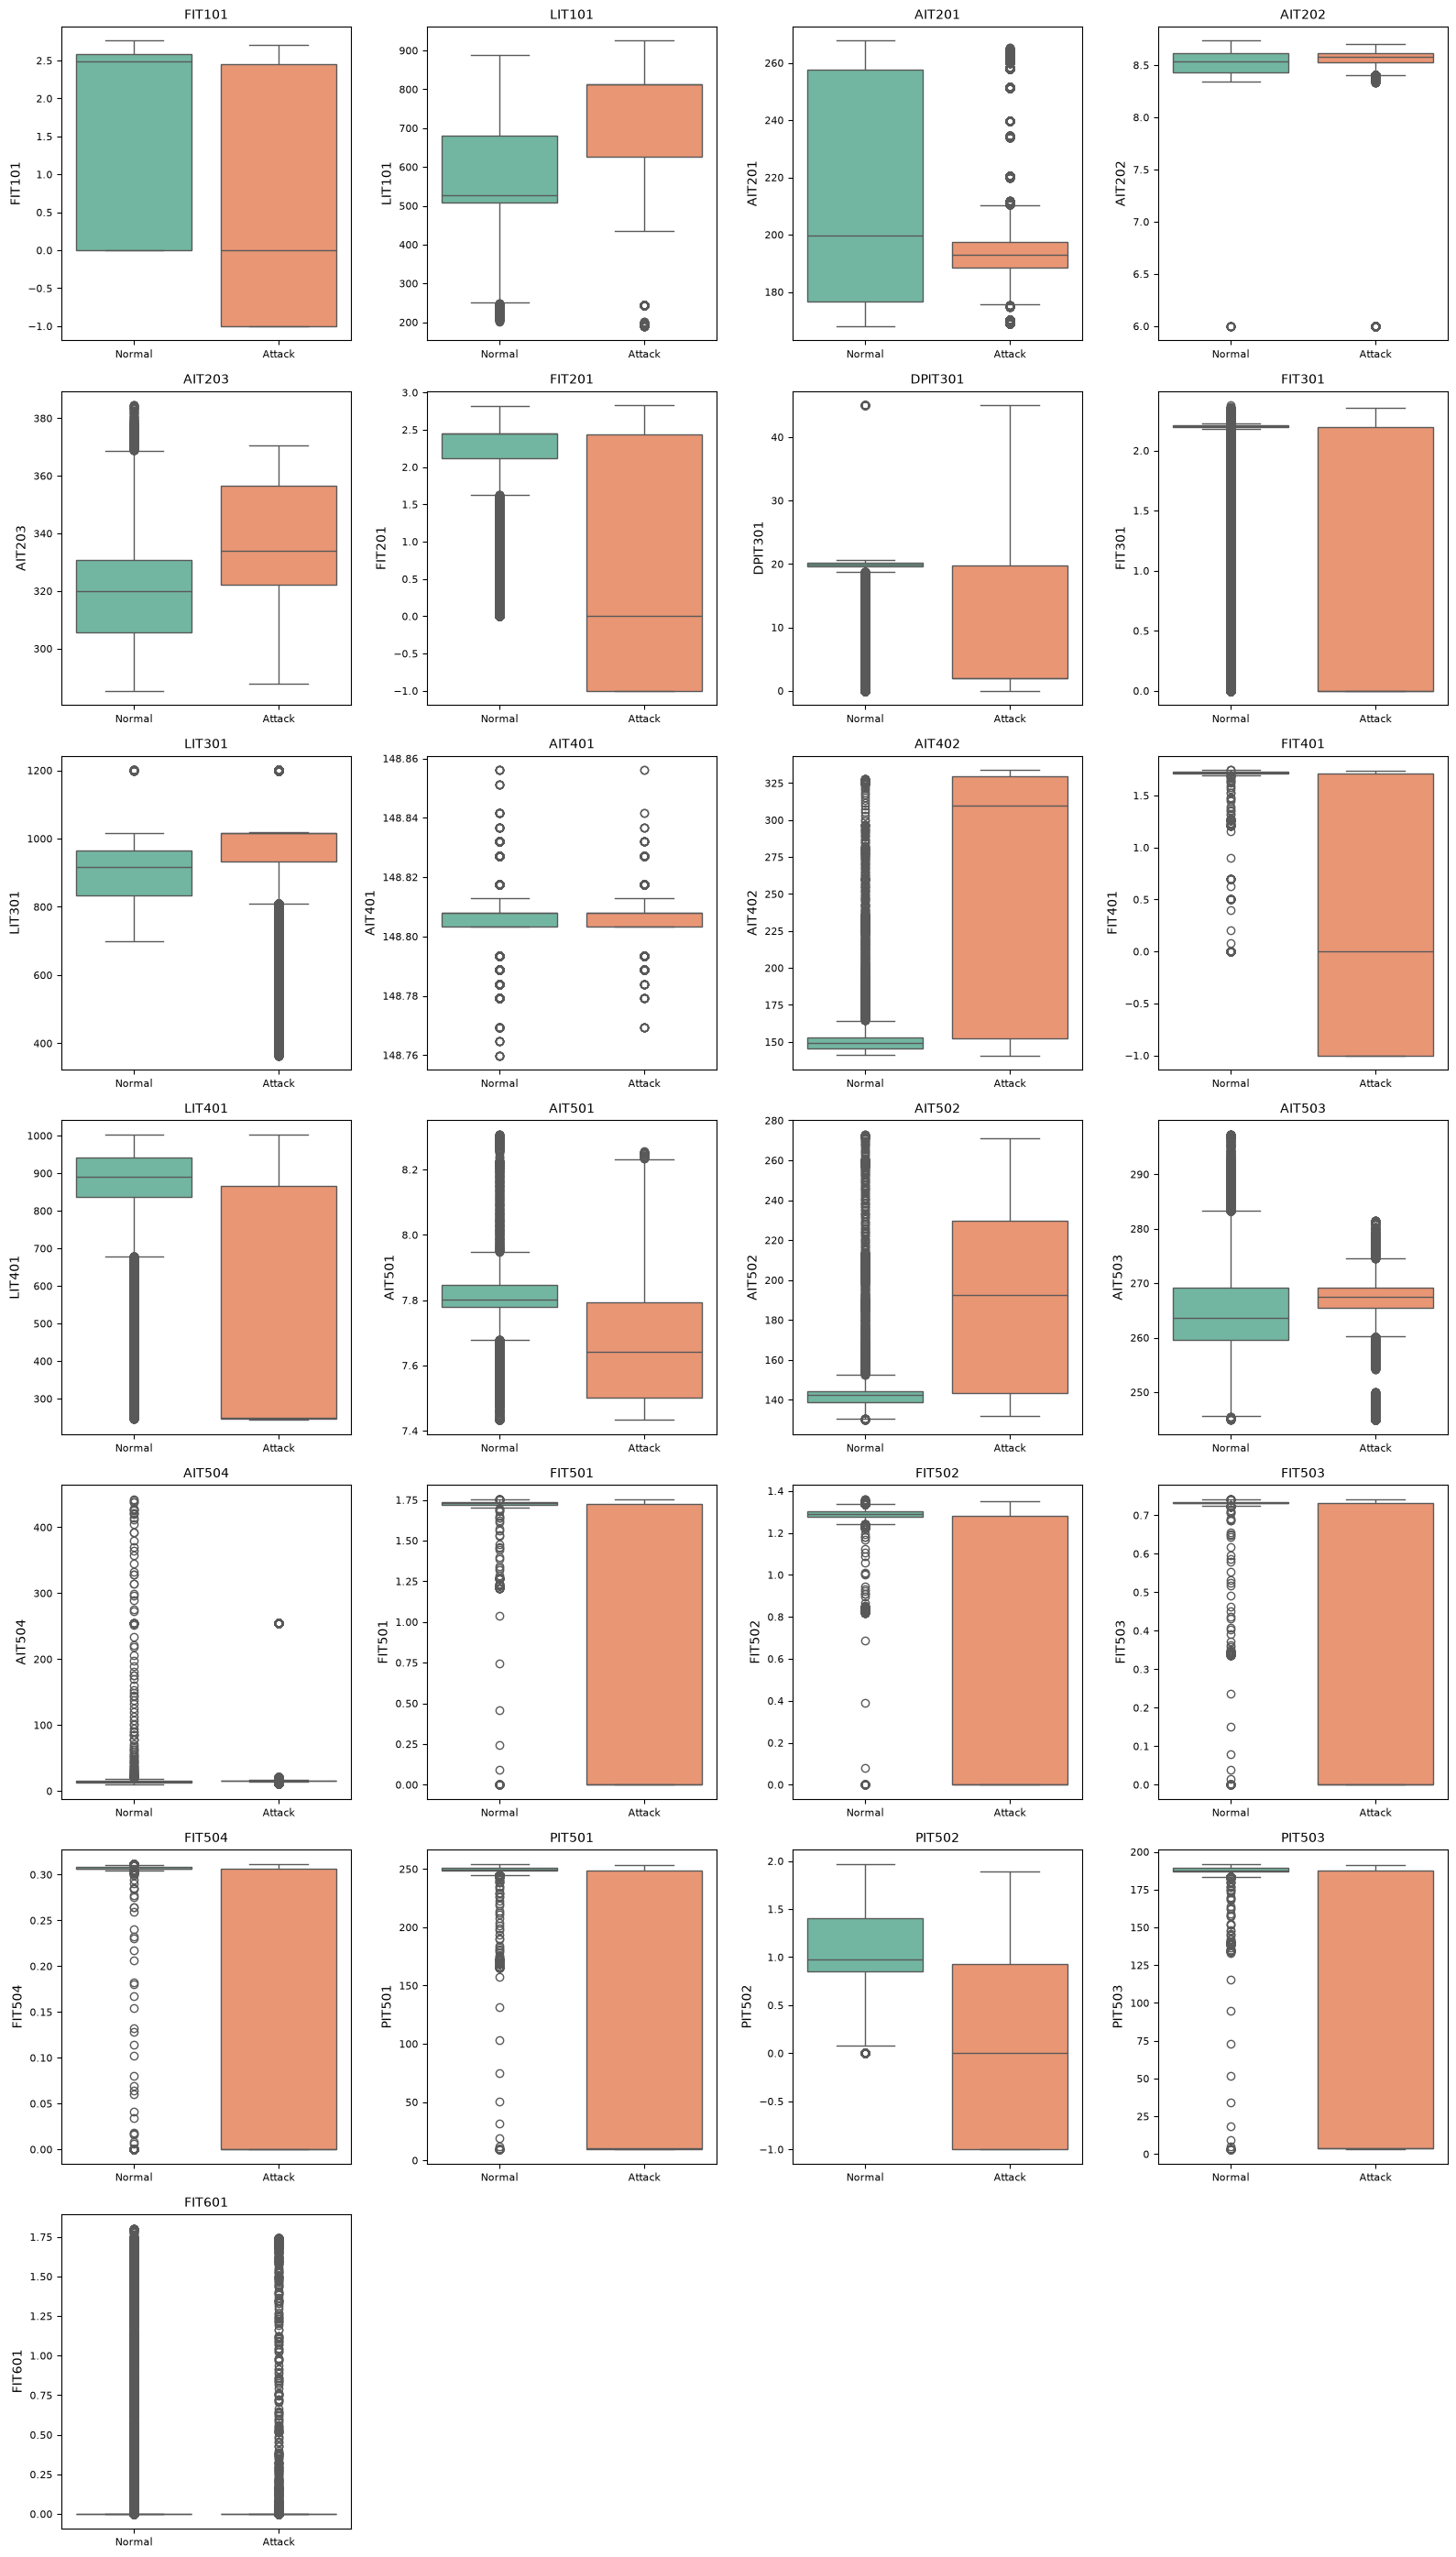

In [28]:
float_cols = df.select_dtypes(include='float64').columns.tolist()

for col in ['Timestamp', 'target']:
    if col in float_cols:
        float_cols.remove(col)

n_cols = 4
n_rows = math.ceil(len(float_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(float_cols):
    ax = axes[i]
    sns.boxplot(x='target', y=col, data=df, ax=ax, palette='Set2')
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')
    ax.set_xticklabels(['Normal', 'Attack'])
    ax.tick_params(labelsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Видно, что много признаков несет достатоно информации об атаке для модели (таргет зависит от данных). Чаще всего атака занижает значения поля.

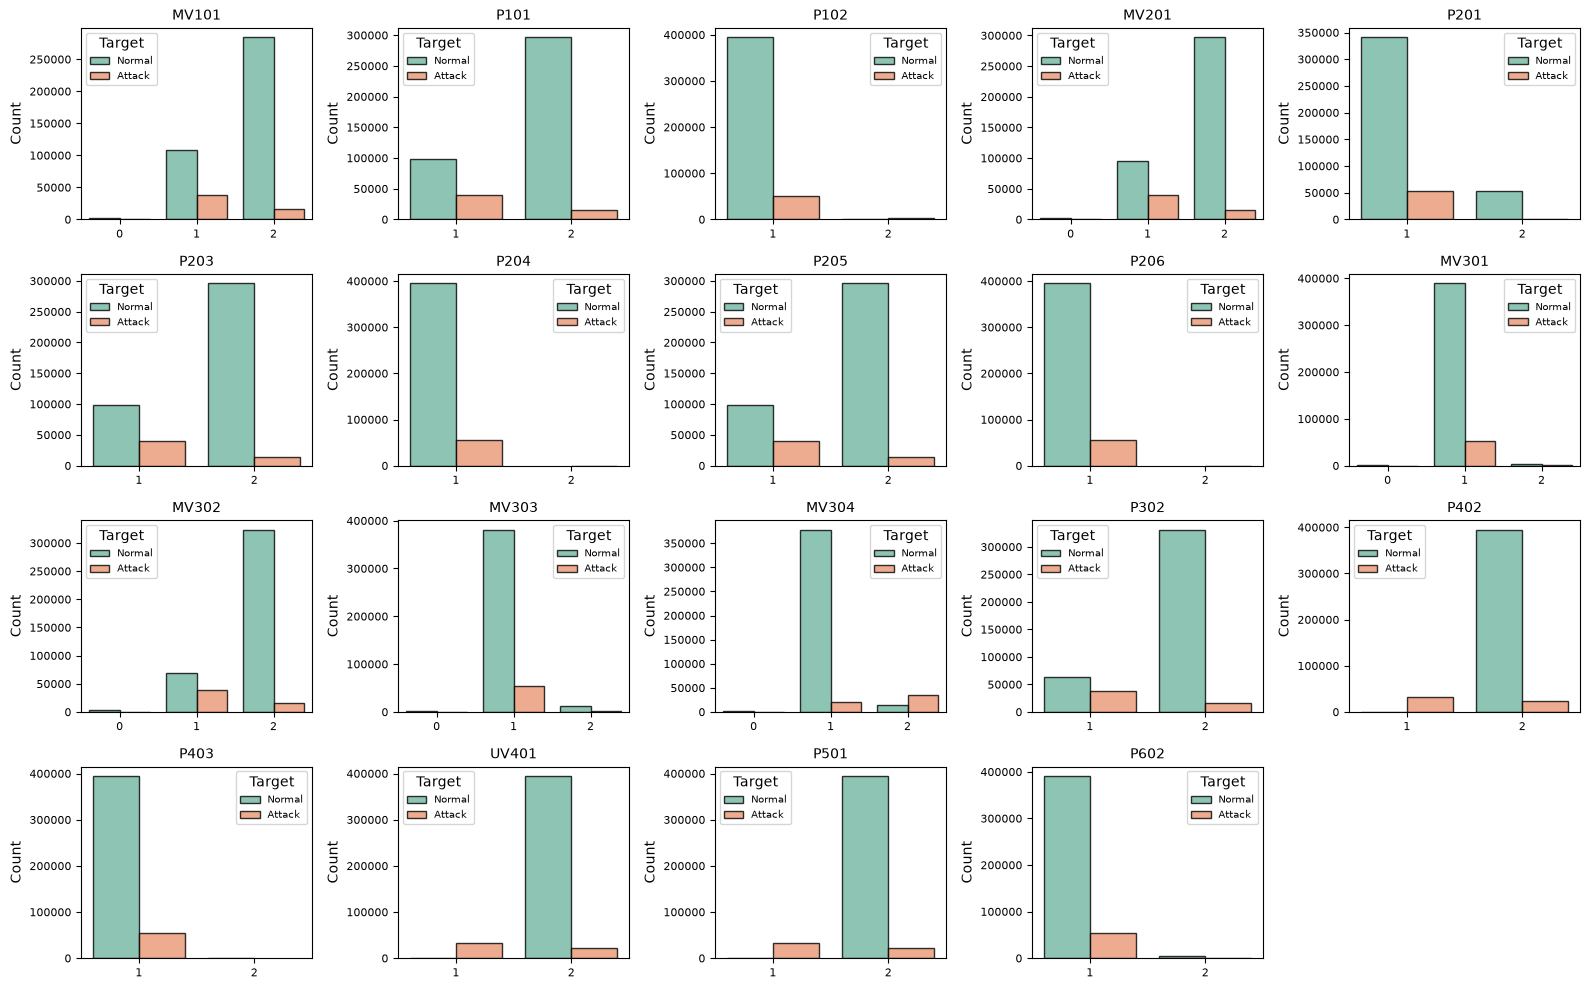

In [29]:
int_cols = df.select_dtypes(include='int64').columns.tolist()

for col in ['target', 'Label']:
    if col in int_cols:
        int_cols.remove(col)

n_cols = 5
n_rows = math.ceil(len(int_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 2.5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(int_cols):
    ax = axes[i]
    sns.countplot(x=col, hue='target', data=df, ax=ax,
                  palette='Set2', edgecolor='black', alpha=0.8)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.legend(title='Target', labels=['Normal', 'Attack'], fontsize=7)
    ax.tick_params(labelsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Дискретные признаки не несут такой явной информации для модели, но и бесполезных признаков среди них больше не осталось

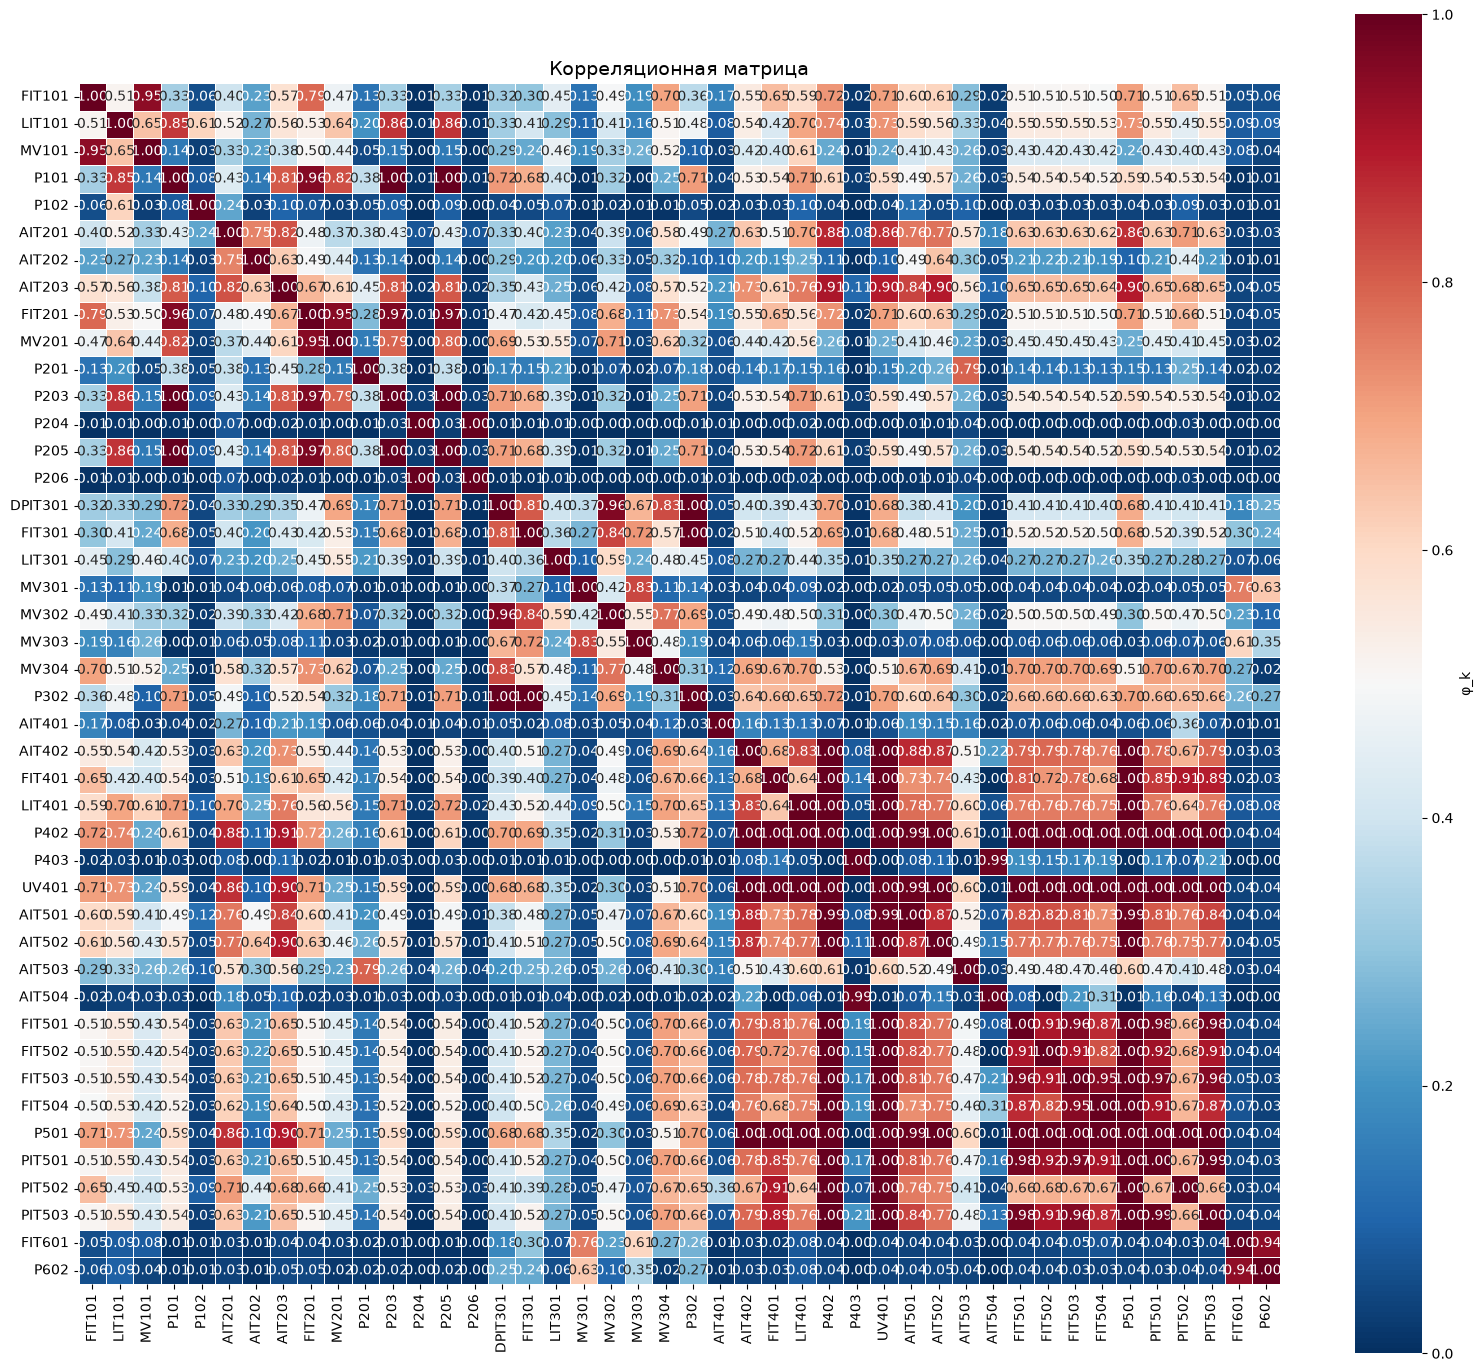

In [30]:
exclude_cols = ['Timestamp', 'target']
features = [col for col in df.columns if col not in exclude_cols]

phik_matrix = df[features].phik_matrix(interval_cols=float_cols)

plt.figure(figsize=(16, 14))
sns.heatmap(phik_matrix, annot=True, fmt='.2f', cmap='RdBu_r', vmin=0, vmax=1,
            linewidths=0.5, square=True, cbar_kws={'label': 'φ_k'})
plt.title('Корреляционная матрица', fontsize=14)
plt.tight_layout()
plt.show()

Признаки P402, UV401 и P501 сильно скоррелированы со множествм других, поэтому стоит их удалить. Как идея их можно попробовать объеденить при помощи PCE. Но для базового решения просто удалим самые скореллированные признки и не будем использовать линейные модели.

In [31]:
df.drop(['P402', 'UV401', 'P501'], axis=1, inplace=True)

# Подготовка к моделированию

In [32]:
df = df.sort_values('Timestamp').reset_index(drop=True)

sensor_cols  = df.select_dtypes(include='float64').columns.tolist()
actuator_cols = df.select_dtypes(include='int64').columns.tolist()
actuator_cols = [c for c in actuator_cols if c != 'target']

print(f"Сенсоры: {len(sensor_cols)}, Актуаторы: {len(actuator_cols)}")

Сенсоры: 25, Актуаторы: 16


Делю фичи на два типа, грубо говоря на float и int, умные названия подсказал гпт

In [33]:
def make_features(df, sensor_cols, actuator_cols):
    feat = pd.DataFrame(index=df.index)
    
    important_lags = [1, 5, 30]  
    windows = [10, 60]          
    
    for col in sensor_cols:
        x = df[col]
        feat[col] = x
        
        for lag in important_lags:
            feat[f'{col}_lag{lag}'] = x.shift(lag)
        
        feat[f'{col}_velocity'] = x.diff(1)
        feat[f'{col}_acceleration'] = x.diff(1).diff(1)
        
        for w in windows:
            rolled = x.shift(1).rolling(w, min_periods=1)
            feat[f'{col}_mean{w}'] = rolled.mean()
            feat[f'{col}_std{w}']  = rolled.std().fillna(0)
            
            feat[f'{col}_zscore{w}'] = (
                (x - rolled.mean()) / (rolled.std() + 1e-8)
            ).fillna(0)
        
        feat[f'{col}_is_extreme'] = (
            (x > x.shift(1).rolling(60).quantile(0.95)) |
            (x < x.shift(1).rolling(60).quantile(0.05))
        ).astype(int)
    
    for col in actuator_cols:
        x = df[col]
        feat[col] = x
        
        change = (x != x.shift(1)).astype(int)
        feat[f'{col}_changed'] = change
        
        feat[f'{col}_switch_rate'] = (
            change.shift(1).rolling(30, min_periods=1).mean()
        )
        
        state_grp = (x != x.shift(1)).cumsum()
        feat[f'{col}_state_duration'] = state_grp.groupby(state_grp).cumcount()
    
    if 'FIT101' in sensor_cols and 'LIT101' in sensor_cols: # отношение расхода к уровню
        feat['FIT_LIT_ratio'] = (
            df['FIT101'] / (df['LIT101'] + 1e-8)
        ).fillna(0)
    
    feat['total_actuators_on'] = df[actuator_cols].sum(axis=1)
    
    sensor_changes = df[sensor_cols].diff(1).abs().sum(axis=1)
    feat['system_volatility'] = sensor_changes.rolling(10).mean().fillna(0)
    
    return feat.fillna(0)

### Признаки для непрерывных значений
**Лаговые признаки** - генерируются при помощи shift (сдвиг назад)
- `_lag1` - сдвиг значений на 1
- `_lag_5` - сдвиг значений на 5
- `_lag30` - сдвиг значений на 30 

(сдвигаются назад, показывают модели значения столбца n шагов назад)
**Производные признаки** - расчитываются как разности
- `_velocity` - производная, первая разность X(t) - X(t-1)
- `_acceleration` - ускорение, вторая разность (X(t) - X(t-1)) - (X(t-1) - X(t-2))

**Скользящие признаки** - генерируются, как статистики по конкретному окну
- `_mean10` - скользящее среднее значение по окну 10 (по предыдущим значениям)
- `_std10` - скользящее стандартное отклонение по окну 10
- `_zscore10` - зет-оценка, показывает, насколько сильно текущее значение отклоняется от среднего уровня. Расчитывается  (x - rolled.mean()) / (rolled.std() + 1e-8), добавляю небольшое число в знаменатель чтобы случайно не поделить на 0, расичтывается тоже по окнам.
- `_mean60`, `_std60`, `_zscore60` - тоже самое, просто размер окна больше
- `_is_extreme` - бинарный признак, если текущее значение столбца выходит за границы 5 и 95 процентиля признак равен 1, если нет, то 0 - показывает насколько признак откланяеся от большинства признаков из распределения

### Признаки для категориальных значений (актуаторов) 
- `_changed` - смотрим на предущее значение, елси оно не равно текущему, то признак равен 1, если такое же то 0, показывает переключается ли датчик в другое состояние
- `_switch_rate` - средняя частота изменений за прошлые 30 шагов, показывает как часто за последние 30 шагов менялось положение датчика в долях единицы
- `_state_duration` - комулятивный признак, показывает сколько измерений подряд признак находится в одном и том же положении

### Кастомные признаки 
- `FIT_LIT_ratio` - счиатется как значение FIT101 разделить на LIT101, показывает долю прибавления воды в первый резервуар
- `total_actuators_on` - количество включенных датчиков, сумма значений в категориальных признаках (на самом деле пока расписывал, понял что признак неверный, потому что не все значения бинарные)
- `system_volatility` - грубо говоря показатель стабильности системы, считам изменение за одно измерение (абсолютное значение) и сичтаем среднее значение по окну 10. Если значение маленькое система стабильна, большое - в ней что-то происходит

---
### PS
Значений много и они будут сильно скореллированные, но насколько я знаю лаговые признаки полезны для задач в которых как такогого временного ряда нет, но полезно учитывать временные признаки. Они показывают моделм что было n шагов назад. И по моей логике такие признаки позволяют модели полностью видеть, что происходит с системой в конкретный момент времени. И линейные модели я не использую, поэтому даже сильная корреляция признаков сильно хуже не сделает, те я удалил в качестве демонстрации, что понимаю как строится матрица корреляции. Скорее для деревянных моделей плохо, что получилось большое количество признаков, но 400 признаков это еще примлио. По хорошему, на работе мы чаще всего используем жадный бэкворд, потому что обучаемся на кластере и ресурсы позволяют (жадный бекворд - это когда мы обучаемся на полном объеме признаков, и каждый раз убираем один самый худший, переобучаемся и так до тех пор пока качество не начнет падать, но это долгий процесс). А призаки которые я удалил на EDA, они не несут смысла для модели, большая часть это просто константы

Много потому что у нас 25 непрерывных признаков и 16 категориальных
25 (исходные) + 25 * 3 (оконные) + 25 * 2 (производные) + 25 * 3 * 2 (скользящие признаки) + 25 (экстримальность значения) + 16(категориальные) + 16 * 3 (доп категориальные) + 3 (кастомные признаки) = 392

In [34]:
feat_df = make_features(df, sensor_cols, actuator_cols)
feat_df['target'] = df['target'].values

feat_df.shape[1]

393

In [35]:
def time_stratified_split(feat_df, n_splits=5, test_ratio=0.2):
    total = len(feat_df)
    block_size = total // n_splits
    
    test_indices = []
    for i in range(n_splits):
        start = i * block_size
        end = start + block_size if i < n_splits-1 else total
        block_test_size = int((end - start) * test_ratio)
        test_indices.extend(range(end - block_test_size, end))
    
    train_indices = [i for i in range(total) if i not in test_indices]
    
    return (
        feat_df.iloc[train_indices],
        feat_df.iloc[test_indices]
    )

Разбивка как для временного ряда, чтобы значения не перемешивались

In [36]:
train_df, test_df = time_stratified_split(feat_df, n_splits=5, test_ratio=0.2)

feature_cols = [c for c in feat_df.columns if c != 'target']
X_train, y_train = train_df[feature_cols], train_df['target']
X_test, y_test = test_df[feature_cols], test_df['target']

print(f"Train: {X_train.shape}, Attack: {y_train.mean()*100:.2f}%")
print(f"Test:  {X_test.shape}, Attack: {y_test.mean()*100:.2f}%")

Train: (359938, 392), Attack: 10.41%
Test:  (89981, 392), Attack: 19.08%


In [37]:
scaler = RobustScaler() 
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# LightGBM

In [38]:
neg, pos = np.bincount(y_train.astype(int))
scale_pos_weight = neg / pos

model = lgb.LGBMClassifier(
    objective        = 'binary',
    metric           = 'auc',
    n_estimators     = 2000,           
    learning_rate    = 0.03,           
    max_depth        = 10,             
    num_leaves       = 127,            
    min_child_samples= 5,             
    subsample        = 0.6,          
    colsample_bytree = 0.7,
    reg_alpha        = 0.05,          
    reg_lambda       = 0.5,
    scale_pos_weight = scale_pos_weight * 2,  
    random_state     = 42,
    n_jobs           = -1,
    verbose          = -1,
)

val_idx = int(len(X_train) * 0.85)
X_tr, y_tr = X_train_scaled[:val_idx], y_train.iloc[:val_idx]
X_val, y_val = X_train_scaled[val_idx:], y_train.iloc[val_idx:]

model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(100, verbose=False),
        lgb.log_evaluation(200)
    ],
)

model.best_iteration_

11

In [39]:
def find_best_threshold(y_true, y_proba, target_recall=0.7):
    prec, rec, thr = precision_recall_curve(y_true, y_proba)
    
    valid_idx = np.where(rec[:-1] >= target_recall)[0]
    
    if len(valid_idx) == 0:
        f1 = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-12)
        best_idx = np.argmax(f1)
        print(f"Не удалось достичь recall={target_recall}")
    else:
        best_idx = valid_idx[np.argmax(prec[valid_idx])]
    
    return thr[best_idx], prec[best_idx], rec[best_idx]

поиск лучшего трешхолда для максимизации пресижна, при высоком реколл, если реколл меньше 0.7 то максимизируем f1

In [40]:
y_proba_lgb = model.predict_proba(X_test_scaled)[:, 1]

best_thr, best_prec, best_rec = find_best_threshold(
    y_test, y_proba_lgb, target_recall=0.70
)

y_pred_lgb = (y_proba_lgb >= best_thr).astype(int)

print(f"Порог: {best_thr:.4f}")
print(f"Precision: {best_prec:.4f}, Recall: {best_rec:.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_lgb):.4f}")
print(classification_report(y_test, y_pred_lgb, target_names=['Normal', 'Attack']))

Порог: 0.1208
Precision: 0.4694, Recall: 0.7139
ROC-AUC: 0.8195
              precision    recall  f1-score   support

      Normal       0.92      0.81      0.86     72813
      Attack       0.47      0.71      0.57     17168

    accuracy                           0.79     89981
   macro avg       0.70      0.76      0.71     89981
weighted avg       0.84      0.79      0.81     89981



# Isolation Forest

In [41]:
X_train_normal = X_train_scaled[y_train == 0]

iso = IsolationForest(
    n_estimators     = 500,            
    max_samples      = 512,            
    contamination    = 0.1,            
    max_features     = 0.8,            
    bootstrap        = True,
    random_state     = 42,
    n_jobs           = -1,
)
iso.fit(X_train_normal)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",500
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",512
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.1
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",0.8
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",True
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


In [42]:
iso_score = -iso.score_samples(X_test_scaled)
best_thr_iso, _, _ = find_best_threshold(y_test, iso_score, target_recall=0.60)
y_pred_iso = (iso_score >= best_thr_iso).astype(int)

print(f"Isolation Forest")
print(classification_report(y_test, y_pred_iso, target_names=['Normal', 'Attack']))

Isolation Forest
              precision    recall  f1-score   support

      Normal       0.92      1.00      0.96     72813
      Attack       0.98      0.64      0.78     17168

    accuracy                           0.93     89981
   macro avg       0.95      0.82      0.87     89981
weighted avg       0.93      0.93      0.92     89981



# Ансамбль бустинг + isolation forest

In [43]:
lgb_norm = MinMaxScaler().fit_transform(y_proba_lgb.reshape(-1, 1)).ravel()
iso_norm = MinMaxScaler().fit_transform(iso_score.reshape(-1, 1)).ravel()

w_lgb, w_iso = 0.8, 0.2
ensemble_score = w_lgb * lgb_norm + w_iso * iso_norm

best_thr_ens, _, _ = find_best_threshold(y_test, ensemble_score, target_recall=0.70)
y_pred_ens = (ensemble_score >= best_thr_ens).astype(int)

print(f"Ансабль (LGB {w_lgb} + IF {w_iso})")
print(classification_report(y_test, y_pred_ens, target_names=['Normal', 'Attack']))

Ансабль (LGB 0.8 + IF 0.2)
              precision    recall  f1-score   support

      Normal       0.92      0.86      0.89     72813
      Attack       0.55      0.70      0.61     17168

    accuracy                           0.83     89981
   macro avg       0.74      0.78      0.75     89981
weighted avg       0.85      0.83      0.84     89981



In [44]:
def attack_aware_smoothing(y_pred, y_proba, window=10, min_proba=0.3):
    result = y_pred.copy()
    
    for i in range(len(y_pred)):
        start = max(0, i - window)
        end = min(len(y_pred), i + window + 1)
        
        window_slice = y_pred[start:end]
        proba_slice = y_proba[start:end]
        
        if (window_slice.sum() >= 3) or (proba_slice.mean() > min_proba):
            result[i] = 1
    
    return result

Попытка сгладить ошибки модели в окне

In [45]:
y_pred_smooth = attack_aware_smoothing(y_pred_ens, ensemble_score, window=10)

print(f"После сглаживания")
print(classification_report(y_test, y_pred_smooth, target_names=['Normal', 'Attack']))
print(f"\nF1 до сглаживания:    {f1_score(y_test, y_pred_ens):.4f}")
print(f"F1 после сглаживания: {f1_score(y_test, y_pred_smooth):.4f}")

После сглаживания
              precision    recall  f1-score   support

      Normal       0.92      0.85      0.88     72813
      Attack       0.52      0.70      0.60     17168

    accuracy                           0.82     89981
   macro avg       0.72      0.78      0.74     89981
weighted avg       0.85      0.82      0.83     89981


F1 до сглаживания:    0.6140
F1 после сглаживания: 0.5994


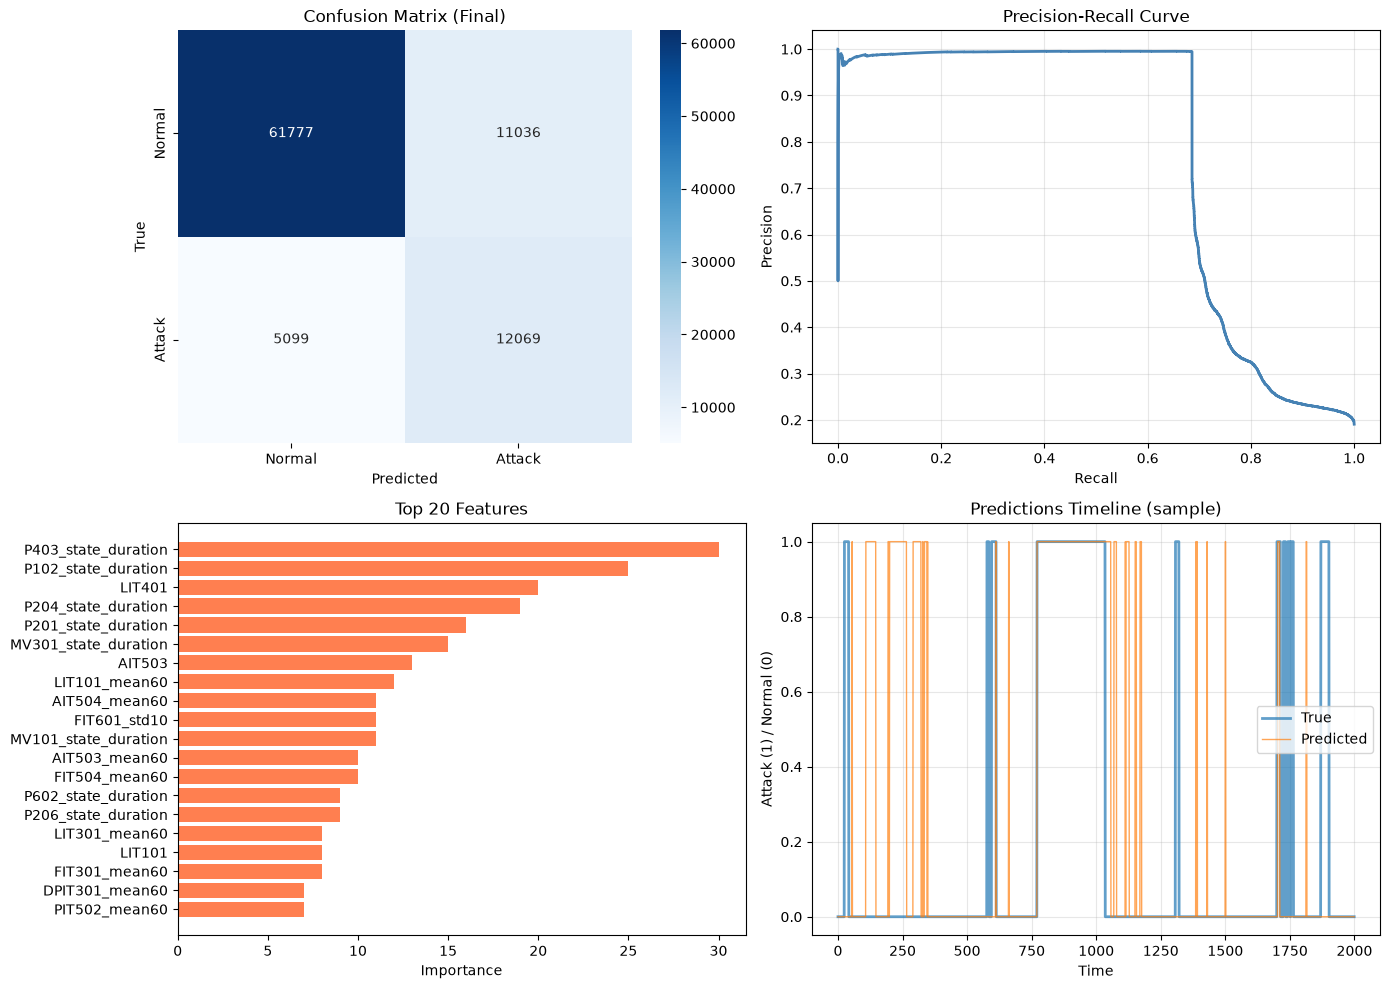

In [46]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

cm = confusion_matrix(y_test, y_pred_smooth)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,0],
            xticklabels=['Normal','Attack'],
            yticklabels=['Normal','Attack'])
axes[0,0].set_title('Confusion Matrix (Final)')
axes[0,0].set_ylabel('True')
axes[0,0].set_xlabel('Predicted')

prec, rec, _ = precision_recall_curve(y_test, ensemble_score)
axes[0,1].plot(rec, prec, color='steelblue', lw=2)
axes[0,1].set_xlabel('Recall')
axes[0,1].set_ylabel('Precision')
axes[0,1].set_title('Precision-Recall Curve')
axes[0,1].grid(alpha=0.3)

importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).head(20)

axes[1,0].barh(importance['feature'], importance['importance'], color='coral')
axes[1,0].set_xlabel('Importance')
axes[1,0].set_title('Top 20 Features')
axes[1,0].invert_yaxis()

sample_size = 2000
sample_idx = np.random.choice(len(y_test), sample_size, replace=False)
sample_idx = np.sort(sample_idx)

axes[1,1].plot(y_test.iloc[sample_idx].values, label='True', alpha=0.7, linewidth=2)
axes[1,1].plot(y_pred_smooth[sample_idx], label='Predicted', alpha=0.7, linewidth=1)
axes[1,1].set_xlabel('Time')
axes[1,1].set_ylabel('Attack (1) / Normal (0)')
axes[1,1].set_title('Predictions Timeline (sample)')
axes[1,1].legend()
axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [47]:
models = {
    'LightGBM': y_pred_lgb,
    'Isolation Forest': y_pred_iso,
    'Ensemble': y_pred_ens,
    'Ensemble + Smoothing': y_pred_smooth
}

results = []
for name, preds in models.items():
    f1 = f1_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    results.append({
        'Model': name,
        'F1': f1,
        'Precision': prec,
        'Recall': rec
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

               Model       F1  Precision   Recall
            LightGBM 0.566405   0.469401 0.713945
    Isolation Forest 0.775356   0.982571 0.640319
            Ensemble 0.614040   0.546869 0.700023
Ensemble + Smoothing 0.599359   0.522354 0.702994


Итоговой лучшей моедлью считаю чистый LightGBM, можно добавить подбор параметров и модель будет еще немного лучше, но в целях экономии ресурсов и времени я этого не делал, возможно, с точки зрения бизнеса другое решение было бы лучше, но тут нужно считать и вводить бизнес показатели и какой-нибудь мнист использовать.

# Что дают признаки 

In [53]:
!pip install shap


[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: C:\test_sibintec\myvenv\Scripts\python.exe -m pip install --upgrade pip


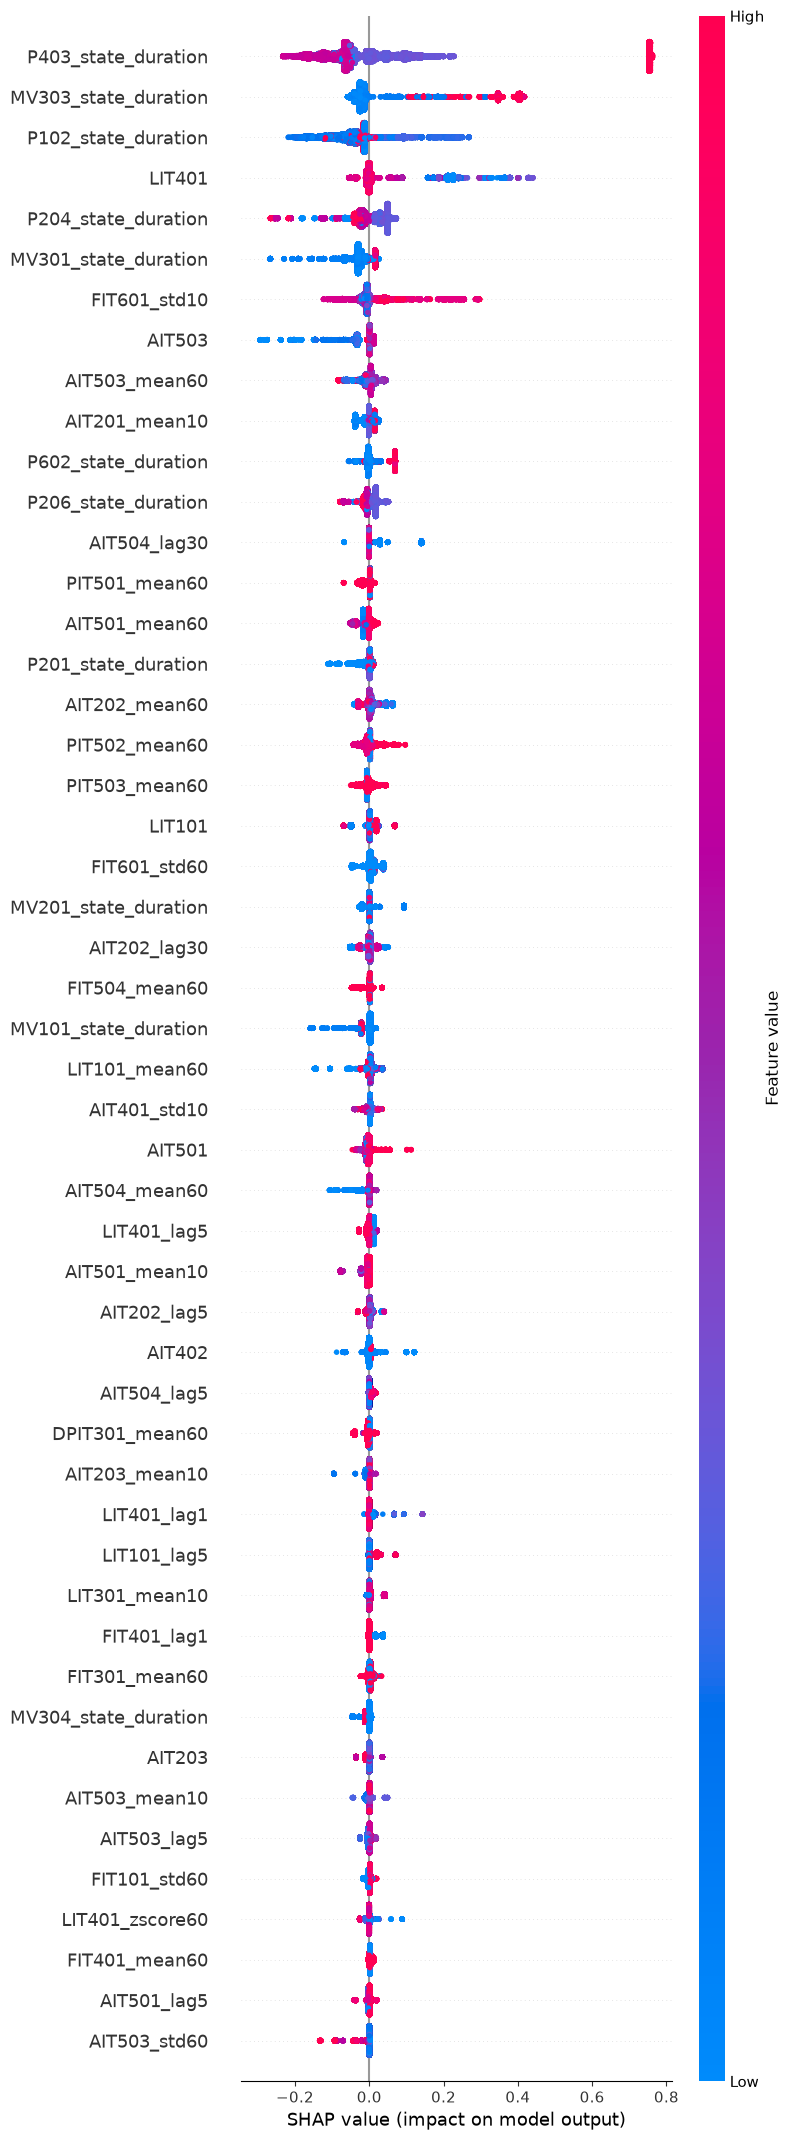

In [58]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_scaled)

if isinstance(shap_values, list):
    shap_attack = shap_values[1]   # класс 1 — атака
    print('if')
else:
    shap_attack = shap_values      # уже матрица для положительного класса

assert len(shap_attack.shape) == 2, "SHAP values are not a matrix!"

shap.summary_plot(
    shap_attack,
    X_test_scaled,
    feature_names=feature_cols,
    max_display=50
)

По графику шепли видно, что на самом деле большую важнсть дают где-то превые 10 признаков, остальные не так сильно. Можно было бы удалить лишниие и переобучить модель. Измерения и график сторил для бустинга так, как по моему он лучшее качество дает.